# Section 1.2.5 — Troisième étape : deuxièmes limites et système à quatre files

On étend le modèle aux deux premières limites de chaque côté du carnet :

$$
Q^{+1}, Q^{+2}\quad \text{côté ask},\qquad
Q^{-1}, Q^{-2}\quad \text{côté bid}.
$$

Les premières limites $Q^{+1}$ et $Q^{-1}$ suivent la dynamique Hawkes de
la section 1.2.4. Les deuxièmes limites $Q^{+2}$ et $Q^{-2}$ ont soit des
intensités constantes, soit une excitation croisée de type

$$
\lambda^{-2,+}(t)
=\mu^{-2,+}
+\int_0^t a\,e^{-b(t-s)}\,dN_s^{-1,-},
$$

et symétriquement côté ask. Cette excitation représente un **rush to queue** :
lorsque la première limite est consommée, des ordres arrivent à la deuxième
limite en anticipation de sa promotion au meilleur prix.


In [15]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model.hawkes_4q import FourQueueParams, simulate_4queue

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

SEED = 42
PARAMS_BASE = dict(
    mu_plus_1=1.2,
    mu_minus_1=1.5,
    alpha=0.3,
    beta=0.5,
    mu_plus_2=0.8,
    mu_minus_2=0.6,
    b_cross=0.5,
    q1_init=10,
    q_neg1_init=10,
    q2_init=5,
    q_neg2_init=5,
)
print(PARAMS_BASE)


{'mu_plus_1': 1.2, 'mu_minus_1': 1.5, 'alpha': 0.3, 'beta': 0.5, 'mu_plus_2': 0.8, 'mu_minus_2': 0.6, 'b_cross': 0.5, 'q1_init': 10, 'q_neg1_init': 10, 'q2_init': 5, 'q_neg2_init': 5}


In [17]:
def collecter_q2_conditionnel(params, n_runs=1_000, T_max=5_000.0, seed=42):
    # Collecte les tailles de deuxième limite au moment où une première limite touche zéro.
    rng = np.random.default_rng(seed)
    q_plus2_when_plus1_zero = []
    q_plus2_when_neg1_zero = []
    q_same = []
    q_opp = []
    which = []
    hitting_times = []

    for _ in range(n_runs):
        res = simulate_4queue(
            params,
            T_max=T_max,
            rng=rng,
            stop_at_first_limit_zero=True,
            record_every=10,
        )
        if not res.hit_zero:
            continue

        w = res.which_hit
        which.append(w)
        hitting_times.append(res.hitting_time)

        q_plus2 = res.q_paths[2][-1]
        q_neg2 = res.q_paths[-2][-1]

        if w == 1:
            q_plus2_when_plus1_zero.append(q_plus2)
            q_same.append(q_plus2)
            q_opp.append(q_neg2)
        elif w == -1:
            q_plus2_when_neg1_zero.append(q_plus2)
            q_same.append(q_neg2)
            q_opp.append(q_plus2)

    return {
        "q_plus2_when_plus1_zero": np.asarray(q_plus2_when_plus1_zero),
        "q_plus2_when_neg1_zero": np.asarray(q_plus2_when_neg1_zero),
        "q_same": np.asarray(q_same),
        "q_opp": np.asarray(q_opp),
        "which": np.asarray(which),
        "hitting_times": np.asarray(hitting_times),
        "n_valid": len(q_same),
    }


def resume_distribution(x):
    x = np.asarray(x)
    return pd.Series({
        "n": len(x),
        "moyenne": np.mean(x) if len(x) else np.nan,
        "écart-type": np.std(x, ddof=1) if len(x) > 1 else np.nan,
        "q05": np.quantile(x, 0.05) if len(x) else np.nan,
        "médiane": np.quantile(x, 0.50) if len(x) else np.nan,
        "q95": np.quantile(x, 0.95) if len(x) else np.nan,
    })


## Question 1.2.5.1a — Distribution de $N_t^{+2}$ sachant $N_t^{+1}=0$

Dans cette question, les deuxièmes limites ont des intensités constantes :
$a_{\mathrm{cross}}=0$. On collecte la taille de $Q^{+2}$ au moment où
$Q^{+1}$ atteint zéro.


In [18]:
params_const = FourQueueParams(**PARAMS_BASE, a_cross=0.0)
N_runs_const = 3_000

res_const = collecter_q2_conditionnel(
    params_const,
    n_runs=N_runs_const,
    T_max=5_000.0,
    seed=SEED,
)

q_plus2_plus1 = res_const["q_plus2_when_plus1_zero"]
resume_distribution(q_plus2_plus1)


n             1527.000000
moyenne          5.737394
écart-type       2.222796
q05              2.000000
médiane          6.000000
q95              9.000000
dtype: float64

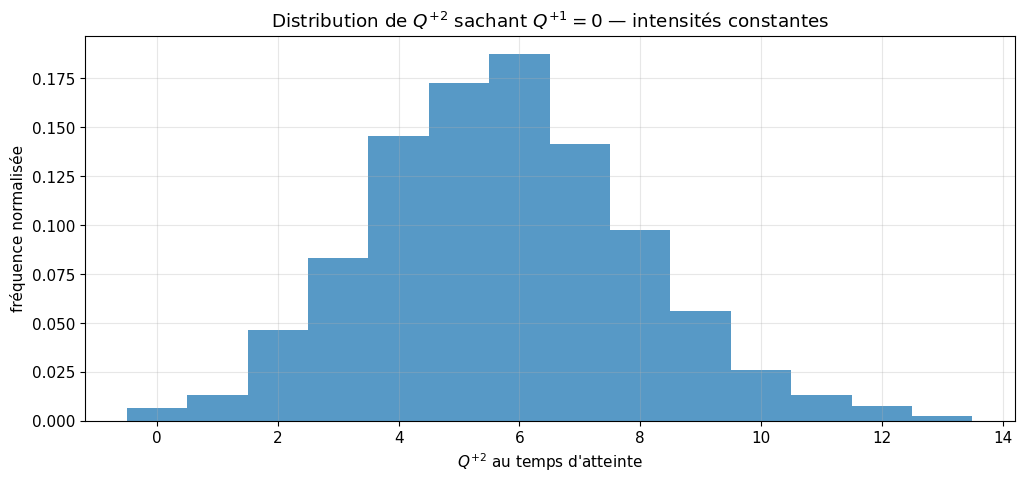

Nombre de simulations valides : 3000 sur 3000
Nombre de cas Q⁺¹=0 : 1527


In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
bins = np.arange(-0.5, max(q_plus2_plus1.max() if len(q_plus2_plus1) else 10, 10) + 1.5, 1)
ax.hist(q_plus2_plus1, bins=bins, density=True, alpha=0.75, color="tab:blue")
ax.set_xlabel(r"$Q^{+2}$ au temps d'atteinte")
ax.set_ylabel("fréquence normalisée")
ax.set_title(r"Distribution de $Q^{+2}$ sachant $Q^{+1}=0$ — intensités constantes")
plt.show()

print(f"Nombre de simulations valides : {res_const['n_valid']} sur {N_runs_const}")
print(f"Nombre de cas Q⁺¹=0 : {len(q_plus2_plus1)}")


**Interprétation.** Avec $a_{\mathrm{cross}}=0$, la deuxième limite évolue
indépendamment du mécanisme de consommation de la première limite, sauf par le
temps aléatoire auquel on l'observe. La distribution obtenue est donc surtout
pilotée par la durée avant déplétion de $Q^{+1}$.


## Question 1.2.5.1b — Distribution de $N_t^{+2}$ sachant $N_t^{-1}=0$

On observe maintenant la même file $Q^{+2}$, mais conditionnellement à la
déplétion de la première limite de l'autre côté, $Q^{-1}=0$. Par symétrie,
les distributions correspondantes pour $Q^{-2}$ sont identiques en loi.


,n,moyenne,écart-type,q05,médiane,q95
Q⁺² | Q⁺¹=0,1527.0,5.737394,2.222796,2.0,6.0,9.0
Q⁺² | Q⁻¹=0,1473.0,5.781399,2.225044,2.0,6.0,10.0


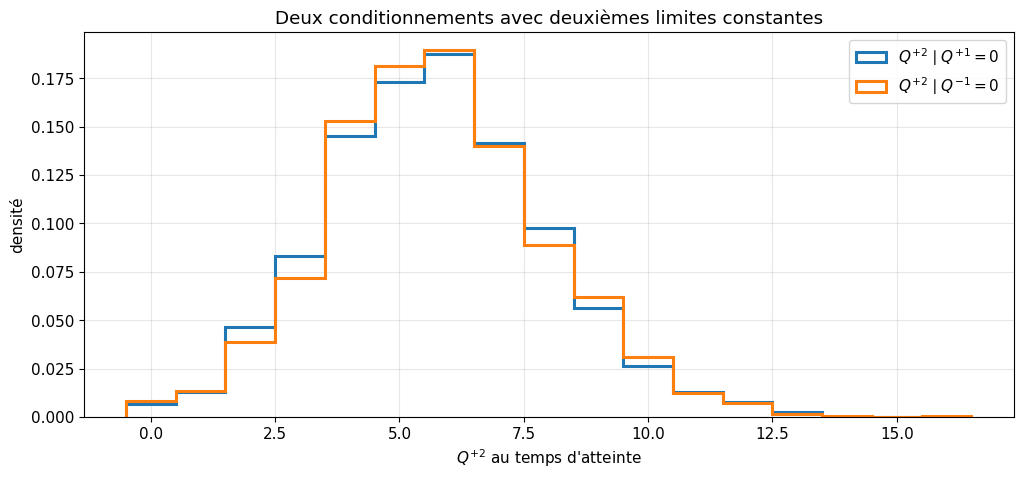

In [20]:
q_plus2_neg1 = res_const["q_plus2_when_neg1_zero"]

table_const = pd.DataFrame({
    "Q⁺² | Q⁺¹=0": resume_distribution(q_plus2_plus1),
    "Q⁺² | Q⁻¹=0": resume_distribution(q_plus2_neg1),
}).T
display(table_const)

max_bin = int(max(
    q_plus2_plus1.max() if len(q_plus2_plus1) else 10,
    q_plus2_neg1.max() if len(q_plus2_neg1) else 10,
    10,
))
bins = np.arange(-0.5, max_bin + 1.5, 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(q_plus2_plus1, bins=bins, density=True, histtype="step", linewidth=2.2, label=r"$Q^{+2}\mid Q^{+1}=0$")
ax.hist(q_plus2_neg1, bins=bins, density=True, histtype="step", linewidth=2.2, label=r"$Q^{+2}\mid Q^{-1}=0$")
ax.set_xlabel(r"$Q^{+2}$ au temps d'atteinte")
ax.set_ylabel("densité")
ax.set_title("Deux conditionnements avec deuxièmes limites constantes")
ax.legend()
plt.show()


**Conclusion.** Les deux distributions sont proches lorsque le système est
symétrique et que les deuxièmes limites ne reçoivent pas d'excitation croisée.
Les écarts résiduels proviennent du bruit Monte Carlo et du conditionnement
par le côté qui se vide en premier.


## Question 1.2.5.2a — Deuxièmes limites avec excitation croisée, même côté

On active maintenant l'équation (4) avec $a_{\mathrm{cross}}>0$ :

$$
\lambda^{+2,+}(t)
=\mu^{+2,+}
+\int_0^t a e^{-b(t-s)}\,dN_s^{+1,-}.
$$

Les retraits de la première limite excitent les ajouts de la deuxième limite
du même côté : c'est l'effet de rush to queue.


In [21]:
a_reference = 0.5
params_exc = FourQueueParams(**PARAMS_BASE, a_cross=a_reference)
N_runs_exc = 3_000

res_exc = collecter_q2_conditionnel(
    params_exc,
    n_runs=N_runs_exc,
    T_max=5_000.0,
    seed=SEED,
)

q_same_exc = res_exc["q_same"]
q_plus2_plus1_exc = res_exc["q_plus2_when_plus1_zero"]

pd.DataFrame({
    "même côté combiné": resume_distribution(q_same_exc),
    "Q⁺² | Q⁺¹=0": resume_distribution(q_plus2_plus1_exc),
}).T


,n,moyenne,écart-type,q05,médiane,q95
même côté combiné,3000.0,11.246667,3.970274,6.0,11.0,19.0
Q⁺² | Q⁺¹=0,1508.0,11.254642,3.991549,6.0,11.0,19.0


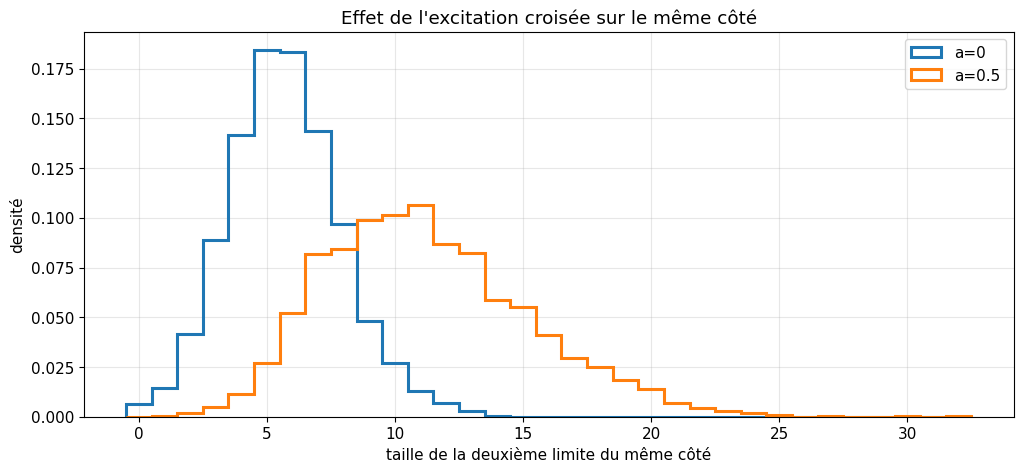

In [22]:
max_bin = int(max(q_same_exc.max() if len(q_same_exc) else 10, res_const["q_same"].max(), 10))
bins = np.arange(-0.5, max_bin + 1.5, 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(res_const["q_same"], bins=bins, density=True, histtype="step", linewidth=2.2, label="a=0")
ax.hist(q_same_exc, bins=bins, density=True, histtype="step", linewidth=2.2, label=f"a={a_reference}")
ax.set_xlabel("taille de la deuxième limite du même côté")
ax.set_ylabel("densité")
ax.set_title("Effet de l'excitation croisée sur le même côté")
ax.legend()
plt.show()


**Interprétation.** L'excitation croisée augmente l'intensité d'ajout de la
deuxième limite lorsque la première limite du même côté est consommée. La
distribution se décale donc vers des files de deuxième limite plus grosses.


## Question 1.2.5.2b — Deuxièmes limites avec excitation croisée, côté opposé

On compare maintenant la taille de $Q^{+2}$ lorsque c'est $Q^{-1}$ qui
touche zéro, ou plus généralement la deuxième limite du côté opposé à la
déplétion. Cette quantité ne reçoit pas directement le même flux d'excitation
que la deuxième limite du côté consommé.


In [23]:
q_opp_exc = res_exc["q_opp"]
q_plus2_neg1_exc = res_exc["q_plus2_when_neg1_zero"]

pd.DataFrame({
    "côté opposé combiné": resume_distribution(q_opp_exc),
    "Q⁺² | Q⁻¹=0": resume_distribution(q_plus2_neg1_exc),
}).T


,n,moyenne,écart-type,q05,médiane,q95
côté opposé combiné,3000.0,10.034667,3.897674,4.0,10.0,17.0
Q⁺² | Q⁻¹=0,1492.0,10.056971,3.994812,4.0,10.0,17.0


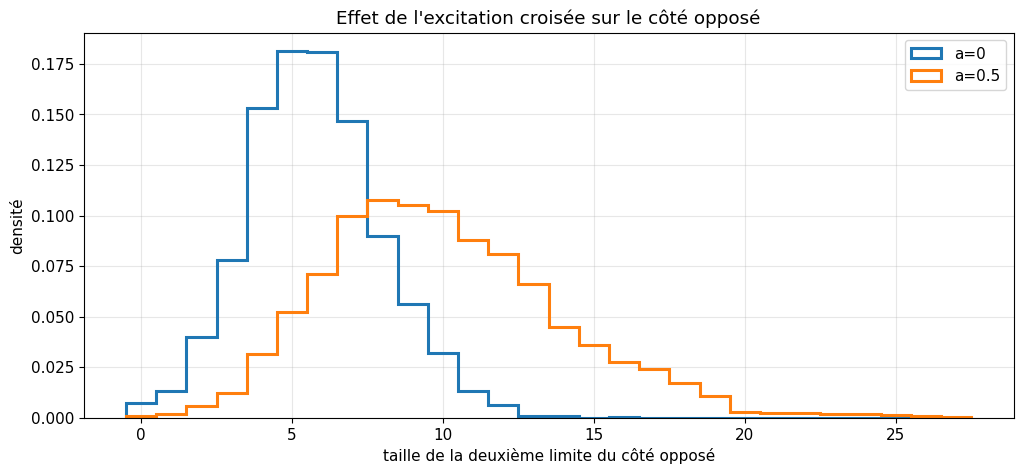

In [24]:
max_bin = int(max(q_opp_exc.max() if len(q_opp_exc) else 10, res_const["q_opp"].max(), 10))
bins = np.arange(-0.5, max_bin + 1.5, 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(res_const["q_opp"], bins=bins, density=True, histtype="step", linewidth=2.2, label="a=0")
ax.hist(q_opp_exc, bins=bins, density=True, histtype="step", linewidth=2.2, label=f"a={a_reference}")
ax.set_xlabel("taille de la deuxième limite du côté opposé")
ax.set_ylabel("densité")
ax.set_title("Effet de l'excitation croisée sur le côté opposé")
ax.legend()
plt.show()


**Conclusion.** Le côté opposé sert de contrôle : il est observé au même temps
d'arrêt, mais il ne bénéficie pas de l'excitation directe provoquée par la
consommation de sa propre première limite. La différence entre les deux
conditionnements mesure donc l'effet local du rush to queue.


## Analyse de sensibilité obligatoire — balayage de $a$

On balaie

$$
a\in\{0,0.2,0.5,1.0,2.0\},\qquad b=0.5.
$$

Pour chaque valeur, on estime les distributions conditionnelles de la
deuxième limite du même côté et du côté opposé.


In [25]:
a_values = [0.0, 0.2, 0.5, 1.0, 2.0]
N_runs_sens = 1_000

sensibilite = {}
for idx, a in enumerate(a_values):
    params = FourQueueParams(**PARAMS_BASE, a_cross=a)
    sensibilite[a] = collecter_q2_conditionnel(
        params,
        n_runs=N_runs_sens,
        T_max=5_000.0,
        seed=SEED + idx,
    )

resume_sens = []
for a, res in sensibilite.items():
    resume_sens.append({
        "a": a,
        "E[Q2_same]": np.mean(res["q_same"]),
        "E[Q2_opp]": np.mean(res["q_opp"]),
        "n_valid": res["n_valid"],
    })
resume_sens = pd.DataFrame(resume_sens)
resume_sens


,a,E[Q2_same],E[Q2_opp],n_valid
0,0.0,5.589,5.741,1000
1,0.2,7.854,7.315,1000
2,0.5,11.422,10.034,1000
3,1.0,17.019,14.481,1000
4,2.0,27.749,22.888,1000


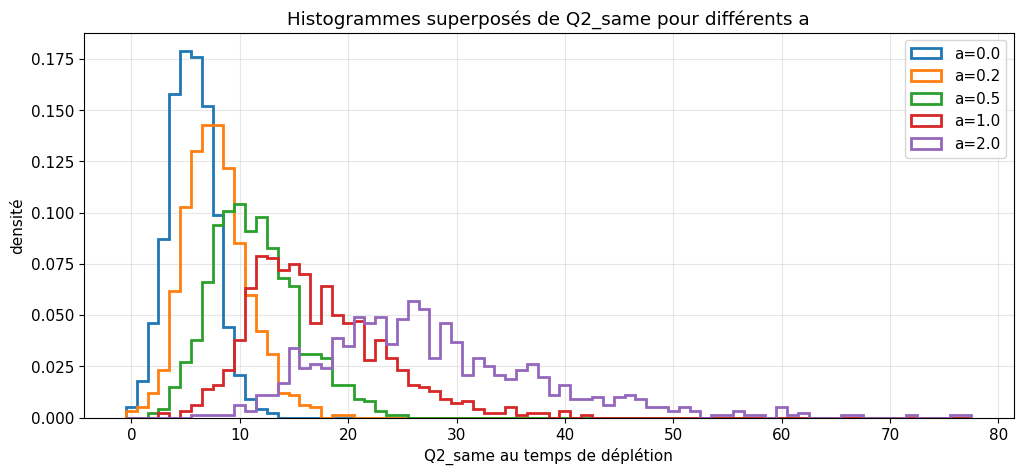

In [26]:
max_same = max(int(np.max(res["q_same"])) for res in sensibilite.values() if len(res["q_same"]))
bins_same = np.arange(-0.5, max_same + 1.5, 1)

fig, ax = plt.subplots(figsize=(12, 5))
for a, res in sensibilite.items():
    ax.hist(res["q_same"], bins=bins_same, density=True, histtype="step", linewidth=2, label=f"a={a}")
ax.set_xlabel("Q2_same au temps de déplétion")
ax.set_ylabel("densité")
ax.set_title("Histogrammes superposés de Q2_same pour différents a")
ax.legend()
plt.show()


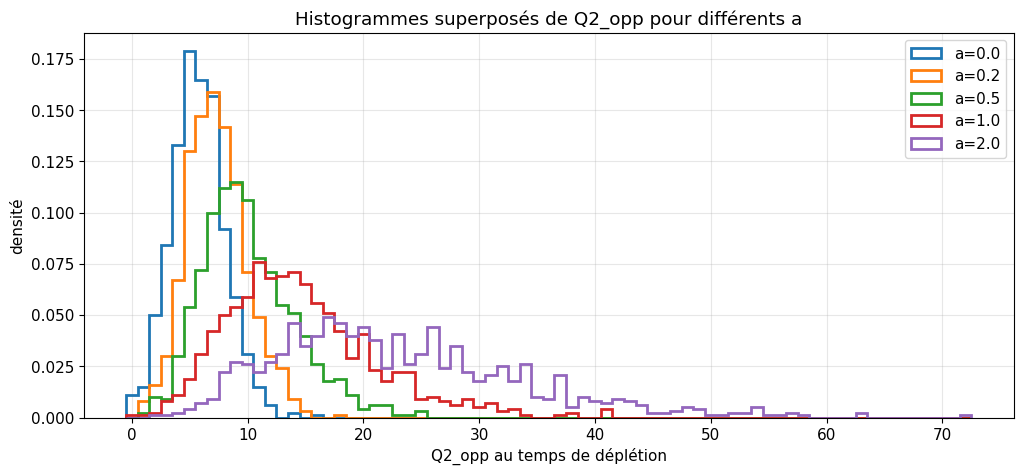

In [27]:
max_opp = max(int(np.max(res["q_opp"])) for res in sensibilite.values() if len(res["q_opp"]))
bins_opp = np.arange(-0.5, max_opp + 1.5, 1)

fig, ax = plt.subplots(figsize=(12, 5))
for a, res in sensibilite.items():
    ax.hist(res["q_opp"], bins=bins_opp, density=True, histtype="step", linewidth=2, label=f"a={a}")
ax.set_xlabel("Q2_opp au temps de déplétion")
ax.set_ylabel("densité")
ax.set_title("Histogrammes superposés de Q2_opp pour différents a")
ax.legend()
plt.show()


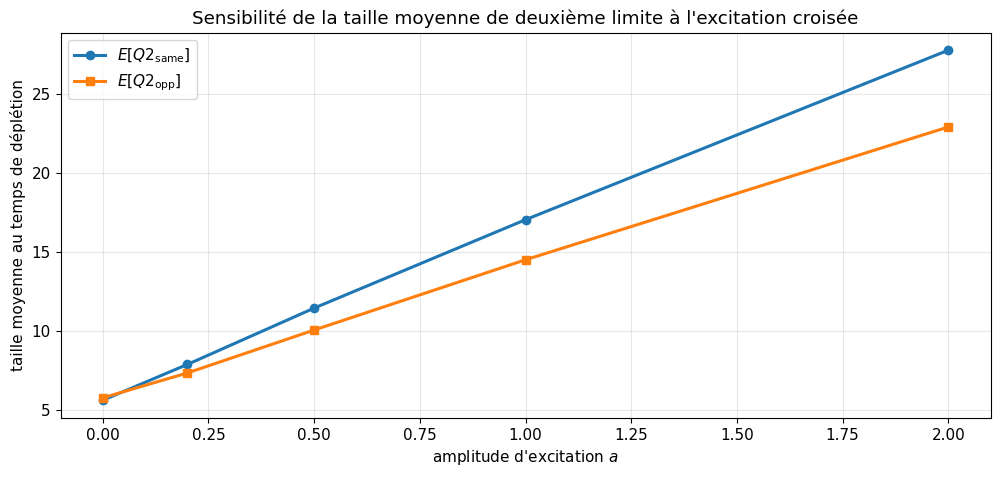

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(resume_sens["a"], resume_sens["E[Q2_same]"], marker="o", linewidth=2.2, label=r"$E[Q2_{\mathrm{same}}]$")
ax.plot(resume_sens["a"], resume_sens["E[Q2_opp]"], marker="s", linewidth=2.2, label=r"$E[Q2_{\mathrm{opp}}]$")
ax.set_xlabel(r"amplitude d'excitation $a$")
ax.set_ylabel("taille moyenne au temps de déplétion")
ax.set_title("Sensibilité de la taille moyenne de deuxième limite à l'excitation croisée")
ax.legend()
plt.show()


**Interprétation finale.** Plus $a$ est grand, plus la deuxième limite du
même côté tend à être grosse lorsque la première limite est consommée. Le
modèle capture ainsi l'afflux de liquidité en anticipation de la promotion de
$Q^{\pm2}$ en nouveau best bid ou best ask. Le côté opposé évolue beaucoup
moins fortement, ce qui confirme que l'effet mesuré est bien local au côté où
la première limite se vide.
